## Column Data Type Classification

| Column Name          | Data Type | Reason                                   |
|:---------------------|:----------|:-----------------------------------------|
| `ID`                 | Nominal   | Unique identifier, no inherent order or magnitude. |
| `Year_Birth`         | Interval  | Differences are meaningful, but no true zero point (year 0). |
| `Education`          | Ordinal   | Categories with a meaningful order (e.g., Basic < Graduation < Master < PhD). |
| `Marital_Status`     | Nominal   | Categories without inherent order.       |
| `Income`             | Ratio     | Has a true zero point, and ratios are meaningful. |
| `Kidhome`            | Ratio     | Has a true zero point, and ratios are meaningful. |
| `Teenhome`           | Ratio     | Has a true zero point, and ratios are meaningful. |
| `Dt_Customer`        | Interval  | Differences in dates are meaningful, but no true zero for the date itself. |
| `Recency`            | Ratio     | Has a true zero point, and ratios are meaningful. |
| `MntWines`           | Ratio     | Amount spent, has a true zero, ratios are meaningful. |
| `MntFruits`          | Ratio     | Amount spent, has a true zero, ratios are meaningful. |
| `MntMeatProducts`    | Ratio     | Amount spent, has a true zero, ratios are meaningful. |
| `MntFishProducts`    | Ratio     | Amount spent, has a true zero, ratios are meaningful. |
| `MntSweetProducts`   | Ratio     | Amount spent, has a true zero, ratios are meaningful. |
| `MntGoldProds`       | Ratio     | Amount spent, has a true zero, ratios are meaningful. |
| `NumDealsPurchases`  | Ratio     | Count of purchases, has a true zero, ratios are meaningful. |
| `NumWebPurchases`    | Ratio     | Count of purchases, has a true zero, ratios are meaningful. |
| `NumCatalogPurchases`| Ratio     | Count of purchases, has a true zero, ratios are meaningful. |
| `NumStorePurchases`  | Ratio     | Count of purchases, has a true zero, ratios are meaningful. |
| `NumWebVisitsMonth`  | Ratio     | Count of visits, has a true zero, ratios are meaningful. |
| `AcceptedCmp3`       | Nominal   | Binary (0/1), represents categories without order. |
| `AcceptedCmp4`       | Nominal   | Binary (0/1), represents categories without order. |
| `AcceptedCmp5`       | Nominal   | Binary (0/1), represents categories without order. |
| `AcceptedCmp1`       | Nominal   | Binary (0/1), represents categories without order. |
| `AcceptedCmp2`       | Nominal   | Binary (0/1), represents categories without order. |
| `Complain`           | Nominal   | Binary (0/1), represents categories without order. |
| `Z_CostContact`      | Ratio     | Numerical scale, likely has a true zero, ratios are meaningful. |
| `Z_Revenue`          | Ratio     | Numerical scale, likely has a true zero, ratios are meaningful. |
| `Response`           | Nominal   | Binary (0/1), represents categories without order. |

In [ ]:
# Code generated using Gemini AI (Google Colab) #A2
import pandas as pd

def label_encode(column: pd.Series) -> pd.Series:
  """
  Performs label encoding on a categorical pandas Series.

  Args:
    column: A pandas Series containing categorical data.

  Returns:
    A pandas Series with integer-encoded values.
  """
  # Use factorize to get numerical representations for each unique category
  # and return the encoded array as a Series. `factorize` returns an integer array for the codes.
  encoded_values, _ = pd.factorize(column)
  return pd.Series(encoded_values, index=column.index, dtype=int)

In [ ]:
# Code generated using Gemini AI (Google Colab) #A2
import pandas as pd

def one_hot_encode(column: pd.Series, prefix: str = None) -> pd.DataFrame:
  """
  Performs one-hot encoding on a categorical pandas Series.

  Args:
    column: A pandas Series containing categorical data.
    prefix: String to append to column names, useful for multiple one-hot encoded columns. If None, uses the column name.

  Returns:
    A pandas DataFrame with one-hot encoded dummy columns.
  """
  # Use get_dummies to create binary columns for each unique category.
  # The 'prefix' argument adds a prefix to the new column names for clarity.
  # `dtype=int` ensures the dummy variables are integers (0 or 1).
  return pd.get_dummies(column, prefix=prefix or column.name, dtype=int)

In [ ]:
# Code generated using Gemini AI (Google Colab) #A3

# Re-initialize df from the 'data' dictionary for a fresh demonstration
# This ensures the original 'Marital_Status' and 'Education' columns are present.
df = pd.DataFrame(data)

print(f"Shape of DataFrame before encoding: {df.shape}")

# Apply label_encode to 'Marital_Status' column
df['Marital_Status_Encoded'] = label_encode(df['Marital_Status'])

# Apply one_hot_encode to 'Education' column
education_one_hot_df = one_hot_encode(df['Education'])

# Drop the original 'Marital_Status' and 'Education' columns
df = df.drop(columns=['Marital_Status', 'Education'])

# Concatenate the one-hot encoded 'Education' columns to the DataFrame
df = pd.concat([df, education_one_hot_df], axis=1)

print(f"Shape of DataFrame after encoding: {df.shape}")

display(df.head())

Shape of DataFrame before encoding: (5, 6)
Shape of DataFrame after encoding: (5, 9)


,ID,Year_Birth,Income,Kidhome,Marital_Status_Encoded,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,1,1980,50000,0,0,0,1,0,0
1,2,1990,60000,1,1,0,0,0,1
2,3,1975,75000,0,2,0,0,1,0
3,4,1982,55000,1,0,0,1,0,0
4,5,1995,40000,0,1,1,0,0,0


In [ ]:
# Code generated using Gemini AI (Google Colab) #A4
import numpy as np

def minkowski_distance(v1, v2, p: int) -> float:
  """
  Computes the generalized Minkowski distance between two numeric vectors.

  Args:
    v1: The first numeric vector (list or numpy array).
    v2: The second numeric vector (list or numpy array).
    p: The order of the Minkowski distance. Must be a positive integer.

  Returns:
    The Minkowski distance as a float.

  Raises:
    ValueError: If p is not a positive integer or if vectors have different lengths.
  """
  if not isinstance(p, int) or p <= 0:
    raise ValueError("The order 'p' must be a positive integer.")

  # Convert inputs to numpy arrays for efficient element-wise operations
  v1 = np.asarray(v1)
  v2 = np.asarray(v2)

  if len(v1) != len(v2):
    raise ValueError("Vectors must have the same length.")

  # Calculate the absolute difference between corresponding elements
  diff = np.abs(v1 - v2)

  # Raise each difference to the power of 'p'
  powered_diff = diff**p

  # Sum the powered differences
  sum_powered_diff = np.sum(powered_diff)

  # Take the p-th root of the sum
  distance = sum_powered_diff**(1/p)

  # Inline comment: When p=1, this calculates the Manhattan distance (L1 norm).
  # It's the sum of the absolute differences of their Cartesian coordinates.
  # e.g., sum(|x_i - y_i|)

  # Inline comment: When p=2, this calculates the Euclidean distance (L2 norm).
  # It's the square root of the sum of the squared differences.
  # e.g., sqrt(sum((x_i - y_i)^2))

  return distance

In [ ]:
# Code generated using Gemini AI (Google Colab) #A5

# Sample vectors for testing
v_a = [1, 2, 3]
v_b = [4, 5, 6]

# Test with p=1 (Manhattan distance)
manhattan_dist = minkowski_distance(v_a, v_b, p=1)
print(f"Minkowski Distance (p=1, Manhattan): {manhattan_dist}")

# Test with p=2 (Euclidean distance)
euclidean_dist = minkowski_distance(v_a, v_b, p=2)
print(f"Minkowski Distance (p=2, Euclidean): {euclidean_dist}")

# Test with a different p value, e.g., p=3
p3_dist = minkowski_distance(v_a, v_b, p=3)
print(f"Minkowski Distance (p=3): {p3_dist}")

# Test with different length vectors to check error handling
try:
  minkowski_distance([1, 2], [1, 2, 3], p=2)
except ValueError as e:
  print(f"Expected error for different length vectors: {e}")

# Test with invalid p value
try:
  minkowski_distance(v_a, v_b, p=0)
except ValueError as e:
  print(f"Expected error for invalid p (p=0): {e}")


Minkowski Distance (p=1, Manhattan): 9.0
Minkowski Distance (p=2, Euclidean): 5.196152422706632
Minkowski Distance (p=3): 4.3267487109222245
Expected error for different length vectors: Vectors must have the same length.
Expected error for invalid p (p=0): The order 'p' must be a positive integer.


Minkowski Distance (p=1): 22.0000
Minkowski Distance (p=2): 10.5830
Minkowski Distance (p=3): 8.5635
Minkowski Distance (p=4): 7.8244
Minkowski Distance (p=5): 7.4746
Minkowski Distance (p=6): 7.2867
Minkowski Distance (p=7): 7.1783
Minkowski Distance (p=8): 7.1130
Minkowski Distance (p=9): 7.0726
Minkowski Distance (p=10): 7.0471


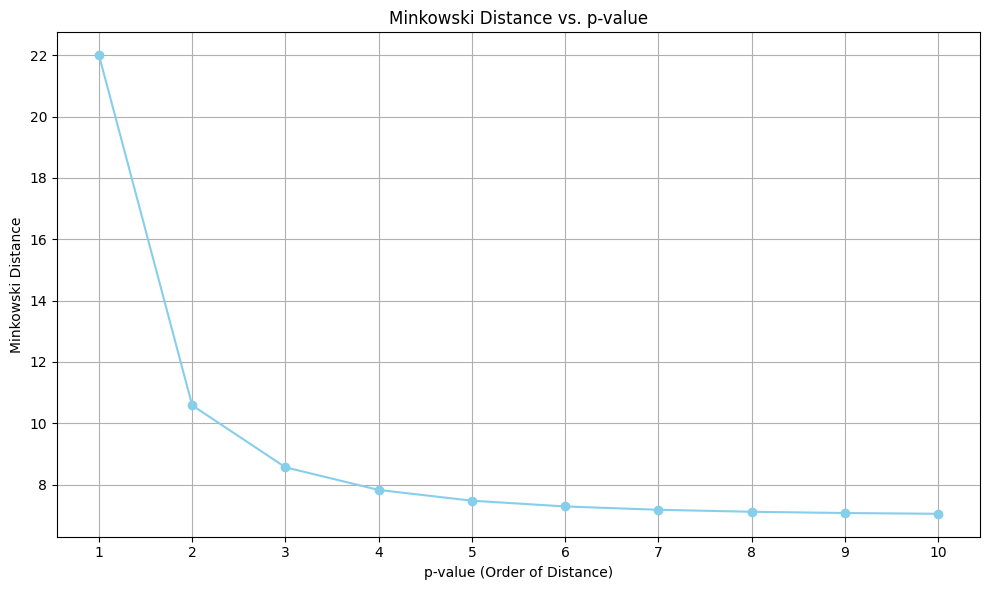

In [ ]:
# Code generated using Gemini AI (Google Colab) #A6
import numpy as np
import matplotlib.pyplot as plt

# Define two sample numeric feature vectors as numpy arrays
v1 = np.array([1, 5, 2, 8, 4])
v2 = np.array([3, 2, 7, 1, 9])

# List to store distances for different p values
distances = []
p_values = range(1, 11) # p from 1 to 10

# Compute Minkowski distance for each p
for p in p_values:
  try:
    dist = minkowski_distance(v1, v2, p)
    distances.append(dist)
    print(f"Minkowski Distance (p={p}): {dist:.4f}")
  except ValueError as e:
    print(f"Error computing distance for p={p}: {e}")
    distances.append(np.nan) # Append NaN if an error occurs

# Plot distance vs p
plt.figure(figsize=(10, 6))
plt.plot(p_values, distances, marker='o', linestyle='-', color='skyblue')
plt.title('Minkowski Distance vs. p-value')
plt.xlabel('p-value (Order of Distance)')
plt.ylabel('Minkowski Distance')
plt.grid(True)
plt.xticks(list(p_values)) # Ensure all p values are shown on x-axis
plt.tight_layout()
plt.show()

In [ ]:
# Code generated using Gemini AI (Google Colab)
import numpy as np
from scipy.spatial.distance import minkowski
import pandas as pd

# Define two sample numeric feature vectors as numpy arrays
v1 = np.array([1, 5, 2, 8, 4])
v2 = np.array([3, 2, 7, 1, 9])

# Lists to store distances for comparison
my_minkowski_distances = []
scipy_minkowski_distances = []
p_values = list(range(1, 11)) # p from 1 to 10

# Compute Minkowski distance for each p using both functions
for p in p_values:
  # My function's distance
  try:
    my_dist = minkowski_distance(v1, v2, p)
    my_minkowski_distances.append(my_dist)
  except ValueError as e:
    my_minkowski_distances.append(f"Error: {e}")

  # SciPy's Minkowski distance
  try:
    scipy_dist = minkowski(v1, v2, p)
    scipy_minkowski_distances.append(scipy_dist)
  except Exception as e:
    scipy_minkowski_distances.append(f"Error: {e}")

# Create a DataFrame for side-by-side comparison
comparison_df = pd.DataFrame({
    'p-value': p_values,
    'My Minkowski Distance': my_minkowski_distances,
    'SciPy Minkowski Distance': scipy_minkowski_distances
})

print("Side-by-side comparison of Minkowski distances:")
display(comparison_df)


Side-by-side comparison of Minkowski distances:


,p-value,My Minkowski Distance,SciPy Minkowski Distance
0,1,22.000000,22.000000
1,2,10.583005,10.583005
2,3,8.563538,8.563538
3,4,7.824379,7.824379
4,5,7.474642,7.474642
5,6,7.286737,7.286737
6,7,7.178319,7.178319
7,8,7.113018,7.113018
8,9,7.072593,7.072593
9,10,7.047097,7.047097


In [ ]:
# Code generated using Claude AI (Anthropic)
# Prompt: "Write two functions: dot_product(v1, v2) and euclidean_norm(v) computed
# manually, then compare with numpy.dot() and numpy.linalg.norm()"

import numpy as np

def dot_product(v1, v2):
    """Compute dot product of two vectors manually."""
    total = 0
    for a, b in zip(v1, v2):
        total += a * b
    return total

def euclidean_norm(v):
    """Compute Euclidean norm (length) of a vector manually."""
    sum_sq = 0
    for a in v:
        sum_sq += a ** 2
    return sum_sq ** 0.5

# Main program
v1 = np.array([2, 4, 6, 8])
v2 = np.array([1, 3, 5, 7])

my_dot = dot_product(v1, v2)
np_dot = np.dot(v1, v2)

my_norm_v1 = euclidean_norm(v1)
np_norm_v1 = np.linalg.norm(v1)

print(f"My dot product: {my_dot}, numpy.dot: {np_dot}")
print(f"My norm of v1: {my_norm_v1:.4f}, numpy.linalg.norm: {np_norm_v1:.4f}")

My dot product: 100, numpy.dot: 100
My norm of v1: 10.9545, numpy.linalg.norm: 10.9545


In [ ]:
#A8,A9 # Code generated using Claude AI (Anthropic)
# Prompt: "Write functions compute_mean, compute_variance, compute_std for a 2D array
# (axis=0), then compare against numpy.mean, numpy.var, numpy.std"

def compute_mean(data):
    """Compute mean of each column (feature) in a 2D array."""
    n_rows, n_cols = data.shape
    means = np.zeros(n_cols)
    for j in range(n_cols):
        col_sum = 0
        for i in range(n_rows):
            col_sum += data[i, j]
        means[j] = col_sum / n_rows
    return means

def compute_variance(data):
    """Compute variance of each column (feature) in a 2D array."""
    n_rows, n_cols = data.shape
    means = compute_mean(data)
    variances = np.zeros(n_cols)
    for j in range(n_cols):
        sq_diff_sum = 0
        for i in range(n_rows):
            sq_diff_sum += (data[i, j] - means[j]) ** 2
        variances[j] = sq_diff_sum / n_rows
    return variances

def compute_std(data):
    """Compute standard deviation of each column (feature) in a 2D array."""
    return np.sqrt(compute_variance(data))

# Main program
feat_matrix = df.select_dtypes(include=[np.number]).to_numpy()

my_means = compute_mean(feat_matrix)
my_vars = compute_variance(feat_matrix)
my_stds = compute_std(feat_matrix)

np_means = np.mean(feat_matrix, axis=0)
np_vars = np.var(feat_matrix, axis=0)
np_stds = np.std(feat_matrix, axis=0)

print("My means:", my_means)
print("Numpy means:", np_means)
print("Mean match:", np.allclose(my_means, np_means))

print("My variances:", my_vars)
print("Numpy variances:", np_vars)
print("Variance match:", np.allclose(my_vars, np_vars))

print("My std devs:", my_stds)
print("Numpy std devs:", np_stds)
print("Std Dev match:", np.allclose(my_stds, np_stds))

My means: [3.0000e+00 1.9844e+03 5.6000e+04 4.0000e-01 8.0000e-01 2.0000e-01
 4.0000e-01 2.0000e-01 2.0000e-01]
Numpy means: [3.0000e+00 1.9844e+03 5.6000e+04 4.0000e-01 8.0000e-01 2.0000e-01
 4.0000e-01 2.0000e-01 2.0000e-01]
Mean match: True
My variances: [2.000e+00 5.144e+01 1.340e+08 2.400e-01 5.600e-01 1.600e-01 2.400e-01
 1.600e-01 1.600e-01]
Numpy variances: [2.000e+00 5.144e+01 1.340e+08 2.400e-01 5.600e-01 1.600e-01 2.400e-01
 1.600e-01 1.600e-01]
Variance match: True
My std devs: [1.41421356e+00 7.17216843e+00 1.15758369e+04 4.89897949e-01
 7.48331477e-01 4.00000000e-01 4.89897949e-01 4.00000000e-01
 4.00000000e-01]
Numpy std devs: [1.41421356e+00 7.17216843e+00 1.15758369e+04 4.89897949e-01
 7.48331477e-01 4.00000000e-01 4.89897949e-01 4.00000000e-01
 4.00000000e-01]
Std Dev match: True


Bin counts: [1 0 1 0 1 1 0 0 0 1]
Bin edges: [40000. 43500. 47000. 50500. 54000. 57500. 61000. 64500. 68000. 71500.
 75000.]


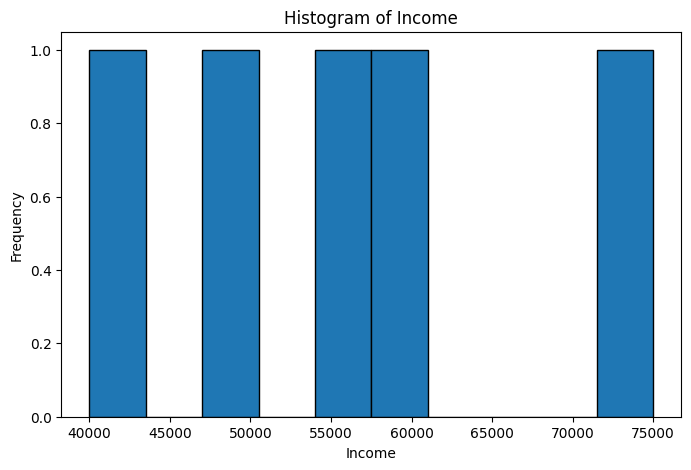

Mean of Income: 56000.00
Variance of Income: 134000000.00


In [ ]:
# Code generated using Claude AI (Anthropic)
# Prompt: "Plot histogram of one feature using numpy.histogram() and matplotlib.pyplot.hist(),
# calculate mean and variance"

import matplotlib.pyplot as plt

# Main program - using Income as example feature
feature = df['Income'].dropna().to_numpy()

counts, bin_edges = np.histogram(feature, bins=10)
print("Bin counts:", counts)
print("Bin edges:", bin_edges)

plt.figure(figsize=(8, 5))
plt.hist(feature, bins=10, edgecolor='black')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Histogram of Income')
plt.show()

feature_mean = compute_mean(feature.reshape(-1, 1))[0]
feature_var = compute_variance(feature.reshape(-1, 1))[0]

print(f"Mean of Income: {feature_mean:.2f}")
print(f"Variance of Income: {feature_var:.2f}")

In [ ]:
# Code generated using Claude AI (Anthropic)
# Prompt: "Write kmeans(data, k, max_iters=100) implementing the basic k-means algorithm:
# select k initial centroids, repeat assign-to-closest-centroid and recompute-centroids,
# until centroids do not change"

def ai_kmeans(data, k, max_iters=100, random_state=42):
    """
    Basic K-means algorithm.
    Steps (Tan, Steinbach, Kumar - Section 8.2):
    1. Select K points as initial centroids
    2. Repeat: assign points to nearest centroid, recompute centroids
    3. Until centroids do not change
    """
    np.random.seed(random_state)
    n_samples = data.shape[0]

    # Step 1: randomly select k initial centroids from data points
    initial_idx = np.random.choice(n_samples, k, replace=False)
    centroids = data[initial_idx].copy()

    for iteration in range(max_iters):
        # Step 2a: assign each point to its closest centroid
        distances = np.zeros((n_samples, k))
        for c in range(k):
            distances[:, c] = np.sqrt(np.sum((data - centroids[c]) ** 2, axis=1))
        labels = np.argmin(distances, axis=1)

        # Step 2b: recompute centroids as mean of assigned points
        new_centroids = np.zeros_like(centroids)
        for c in range(k):
            points_in_cluster = data[labels == c]
            if len(points_in_cluster) > 0:
                new_centroids[c] = points_in_cluster.mean(axis=0)
            else:
                new_centroids[c] = centroids[c]  # keep old centroid if empty cluster

        # Step 3: stop if centroids do not change
        if np.allclose(centroids, new_centroids):
            print(f"Converged after {iteration + 1} iterations")
            break
        centroids = new_centroids

    return centroids, labels

# Main program
data_matrix = df.select_dtypes(include=[np.number]).dropna().to_numpy()
k = 3

centroids, labels = ai_kmeans(data_matrix, k)
print(f"Final centroids shape: {centroids.shape}")
print(f"Cluster label counts: {np.bincount(labels)}")

Converged after 2 iterations
Final centroids shape: (3, 9)
Cluster label counts: [3 1 1]


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset

df = pd.read_excel('Lab Session Data.xlsx', sheet_name='marketing_campaign')
def ai_kmeans(data, k, max_iters=100, random_state=42):
    """
    Basic K-means algorithm implementation.
    """
    np.random.seed(random_state)
    n_samples = data.shape[0]

    # Step 1: Randomly select k initial centroids from data points
    initial_idx = np.random.choice(n_samples, k, replace=False)
    centroids = data[initial_idx].copy()

    for iteration in range(max_iters):
        # Step 2a: Assign each point to its closest centroid
        distances = np.zeros((n_samples, k))
        for c in range(k):
            distances[:, c] = np.sqrt(np.sum((data - centroids[c]) ** 2, axis=1))
        labels = np.argmin(distances, axis=1)

        # Step 2b: Recompute centroids as mean of assigned points
        new_centroids = np.zeros_like(centroids)
        for c in range(k):
            points_in_cluster = data[labels == c]
            if len(points_in_cluster) > 0:
                new_centroids[c] = points_in_cluster.mean(axis=0)
            else:
                new_centroids[c] = centroids[c]  # Keep old centroid if empty cluster

        # Step 3: Stop if centroids do not change
        if np.allclose(centroids, new_centroids):
            print(f"Converged after {iteration + 1} iterations")
            break
        centroids = new_centroids

    return centroids, labels  # Fixed typo here from 'labelsa'

# Main execution logic
data_matrix = df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')
data_matrix = data_matrix.fillna(data_matrix.mean(numeric_only=True)).to_numpy()

k = 3
centroids, labels = ai_kmeans(data_matrix, k)
print(f"Final centroids shape: {centroids.shape}")
print(f"Cluster label counts: {np.bincount(labels)}")

Converged after 28 iterations
Final centroids shape: (3, 25)
Cluster label counts: [854 604 782]
